In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:


from roboflow import Roboflow
rf = Roboflow(api_key="bmGVZBCRbq9QJpAbOxBE")
project = rf.workspace("sayaks-workspace-qffwf").project("thermal-flame-and-smoke-detect-oqs9r")
version = project.version(1)
dataset = version.download("yolov8-obb")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Thermal-Flame-and-Smoke-Detect-1 in yolov8-obb:: 100%|██████████| 1283/1283 [00:00<00:00, 8654.54it/s]


In [3]:
import os

BASE_PATH = "/content/Thermal-Flame-and-Smoke-Detect-1"

splits = ["train", "valid", "test"]
image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def count_images(split):
    img_dir = os.path.join(BASE_PATH, split, "images")
    if not os.path.exists(img_dir):
        return 0
    return len([
        f for f in os.listdir(img_dir)
        if f.lower().endswith(image_exts)
    ])

print(" Dataset image counts:\n")

total = 0
for split in splits:
    n = count_images(split)
    total += n
    print(f"{split.capitalize():<6}: {n}")

print(f"\nTotal images: {total}")

 Dataset image counts:

Train : 524
Valid : 87
Test  : 25

Total images: 636


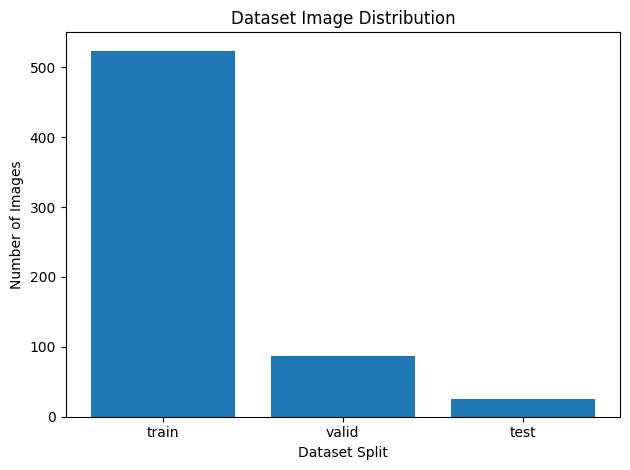

In [4]:
import os
import matplotlib.pyplot as plt

def count_images(split):
    img_dir = os.path.join(BASE_PATH, split, "images")
    if not os.path.exists(img_dir):
        return 0
    return len([
        f for f in os.listdir(img_dir)
        if f.lower().endswith(image_exts)
    ])

counts = [count_images(s) for s in splits]

plt.figure()
plt.bar(splits, counts)
plt.title("Dataset Image Distribution")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

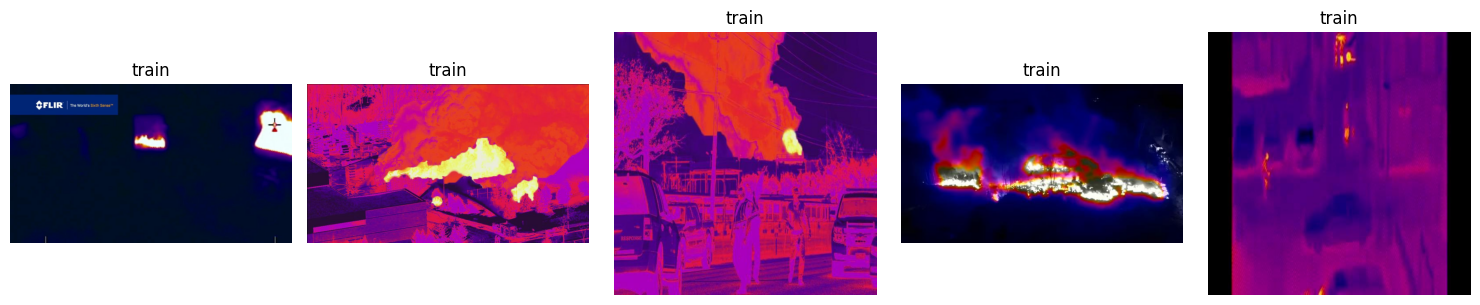

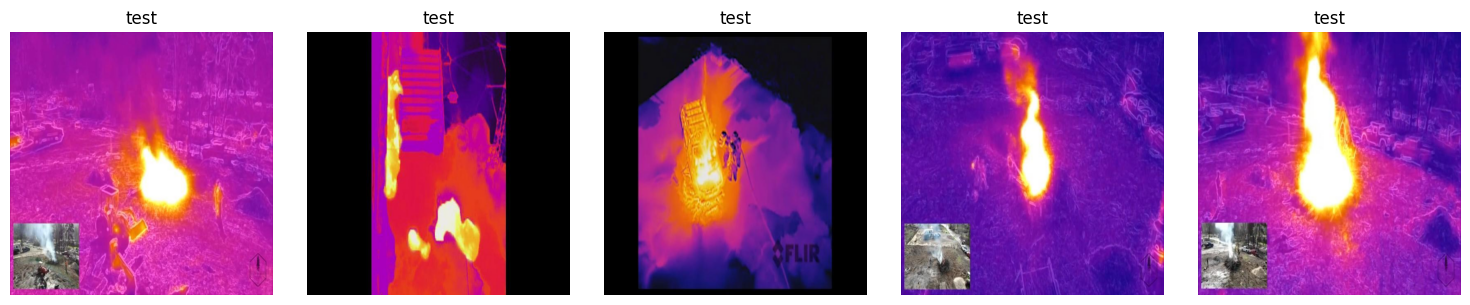

In [5]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def show_images(split, num_images=5):
    img_dir = os.path.join(BASE_PATH, split, "images")
    images = [
        f for f in os.listdir(img_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
    ]

    images = random.sample(images, min(num_images, len(images)))

    plt.figure(figsize=(15, 3))
    for i, img_name in enumerate(images):
        img_path = os.path.join(img_dir, img_name)
        img = Image.open(img_path)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{split}")

    plt.tight_layout()
    plt.show()


# Show samples
show_images("train", num_images=5)
show_images("test", num_images=5)

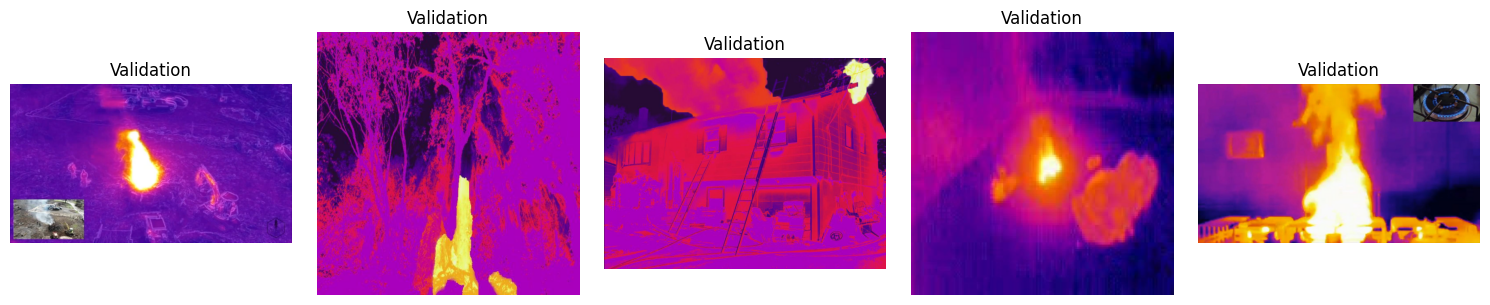

In [6]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

BASE_PATH = "/content/Thermal-Flame-and-Smoke-Detect-1"

def show_val_images(num_images=5):
    img_dir = os.path.join(BASE_PATH, "valid", "images")

    images = [
        f for f in os.listdir(img_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
    ]

    images = random.sample(images, min(num_images, len(images)))

    plt.figure(figsize=(15, 3))
    for i, img_name in enumerate(images):
        img_path = os.path.join(img_dir, img_name)
        img = Image.open(img_path)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title("Validation")

    plt.tight_layout()
    plt.show()


show_val_images(num_images=5)

In [9]:
from ultralytics import YOLO


model = YOLO("yolov8s.pt")  # pretrained on COCO



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
model.train(
    data="/content/Thermal-Flame-and-Smoke-Detect-1/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device=0,        # GPU
    project="fire_detection",
    name="yolov8_fire",
    patience=10      # early stopping
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Thermal-Flame-and-Smoke-Detect-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_fire, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f531b5628a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [14]:
metrics = model.val(
    data="/content/Thermal-Flame-and-Smoke-Detect-1/data.yaml",
    split="test",
    verbose=False
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 690.5±157.9 MB/s, size: 25.0 KB)
val: Scanning /content/Thermal-Flame-and-Smoke-Detect-1/test/labels.cache... 25 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 25/25 7.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.5it/s 1.3s
                   all         25         29      0.781      0.897      0.872      0.574
Speed: 10.5ms preprocess, 11.5ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val3


In [16]:
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

mAP50: 0.8989858344089202
mAP50-95: 0.5207803357830549
Precision: 0.9042260813980572
Recall: 0.7867906740556531


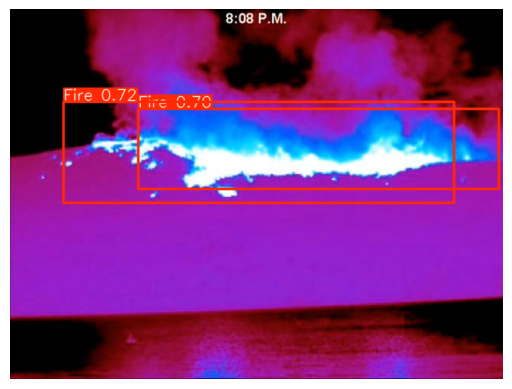

In [40]:
import cv2
import numpy as np

def preprocess_thermal_image_safe(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to read image: {img_path}")

    # Handle 16-bit thermal
    if img.dtype == np.uint16:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
        img = img.astype(np.uint8)

    # Handle float images
    if img.dtype == np.float32 or img.dtype == np.float64:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
        img = img.astype(np.uint8)

    # Grayscale → BGR
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Final safety check
    if img.ndim != 3 or img.shape[2] != 3:
        raise ValueError(f"Invalid image shape after preprocessing: {img.shape}")

    return img

from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("/content/runs/detect/fire_detection/yolov8_fire/weights/best.pt")

img_path = "/content/Thermal-Flame-and-Smoke-Detect-1/valid/images/Terrace-Mountain-Forest-Fire-Growth-August-1-2-22-screenshot_png.rf.211f30fe711f72757267b5c6dc8b27c8.jpg"

img = preprocess_thermal_image_safe(img_path)

# IMPORTANT: wrap in a list
results = model.predict(
    source=[img],
    conf=0.25,
    verbose=False
)

result = results[0]
annotated = result.plot()

plt.imshow(annotated)
plt.axis("off")
plt.show()